# Advanced: Comparison with HALO-(AC)³ aircraft measurements (2)

Here, we simulate the irradiance at 15 output altitudes along the flight path of the HALO, P5 and P6 aircraft during the HALO-(AC)³ campaign. The timesteps are filtered for cloud-free conditions. Later, we compare the pyradtran simulation results to the results published in [Becker et al. (2023)](https://doi.pangaea.de/10.1594/PANGAEA.963654).

In [21]:
# Import PyRadtran components
from pyradtran.config import PathsConfig, SimulationDefaults, SimulationConfig, ExecutionConfig, OutputConfig, load_config
from pyradtran.core import Simulation, generate_input_content
from pyradtran.io import parse_uvspec_output
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import os
import yaml
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('config/halo-ac3_bbr_all_aircraft.ipynb.yaml')
import logging
# Configure logging for pyradtran
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

In [22]:
df = pd.read_csv('data/HALO-AC3_HALO_P5_P6_aircraft_broadband_radiation_clear_sky_with_ocean_100s.csv', parse_dates=['time'])
df = df.set_index('time')

In [23]:
ds = xr.Dataset.from_dataframe(df).drop_duplicates('time').sortby('time')
ds_to_sim = ds.rename({'Lat' : 'latitude', 'Lon' : 'longitude', 'Alt' : 'altitude'}).drop_vars('altitude')
ds_to_sim['altitude'] = ('altitude', np.arange(0, 15))
ds_to_sim['F_down_solar'].loc[{'time' : ds_to_sim.F_down_solar_uncorr.notnull()}] = ds_to_sim.F_down_solar_uncorr.loc[{'time' : ds_to_sim.F_down_solar_uncorr.notnull()}]

In [24]:
# ds = xr.open_dataset('data/HALO-AC3_HALO_aircraft_broadband_radiation_clear_sky_with_ocean_600s.nc').interpolate_na('time')
# # the albedo has over 30% missing values, so we interpolate it for now
# ds
albedo = ((ds_to_sim['F_up_solar'] / ds_to_sim['F_down_solar']) > 1)
ds_to_sim['albedo'] = ('time', albedo.astype(float).values)
ds_to_sim['albedo'] = ds_to_sim['albedo'].fillna(0.5)  # Fill NaN values with a default albedo of 0.3

In [25]:
ds_to_sim

<xarray.Dataset> Size: 29kB
Dimensions:              (time: 215, altitude: 15)
Coordinates:
  * time                 (time) datetime64[ns] 2kB 2022-03-12T12:03:20 ... 20...
  * altitude             (altitude) int64 120B 0 1 2 3 4 5 ... 9 10 11 12 13 14
Data variables: (12/16)
    F_net                (time) float64 2kB nan -124.4 -126.2 ... -50.41 nan
    F_net_terrestrial    (time) float64 2kB nan -142.6 -145.0 ... -82.58 nan
    F_down_terrestrial   (time) float64 2kB nan 13.67 13.4 ... 136.5 140.2 nan
    F_net_solar          (time) float64 2kB nan 18.22 18.75 ... 31.08 32.17 nan
    latitude             (time) float64 2kB 77.52 77.5 77.54 ... 88.46 87.96
    longitude            (time) float64 2kB -9.577 -9.274 -9.53 ... 10.84 -3.578
    ...                   ...
    F_down_solar_sim     (time) float64 2kB 193.6 126.8 125.8 ... 185.5 209.9
    airplane             (time) object 2kB 'HALO' 'HALO' ... 'HALO' 'HALO'
    F_down_solar_corr    (time) float64 2kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    F_down_solar         (time) float64 2kB nan 120.1 119.0 ... 138.8 132.0 nan
    F_down_solar_uncorr  (time) float64 2kB nan nan nan nan ... nan nan nan nan
    albedo               (time) float64 2kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [6]:
# Run a spectral simulation for the dataset
print("Running batch spectral simulation...")
ds_sim = ds_to_sim.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    output_path='data/Simulated_HALO-AC3_HALO_P5_P6_aircraft_broadband_radiation_clear_sky_with_ocean_100s.nc',
    albedo_var='albedo',
    parameter_overrides={
        'aerosol_default' : '\n',
    }
)

print("\nSimulation complete!")
ds_sim

Running batch spectral simulation...



Simulation complete!


<xarray.Dataset> Size: 186kB
Dimensions:    (time: 215, altitude: 15)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2022-03-12T12:03:20 ... 2022-04-12T1...
    latitude   (time) float64 2kB 77.52 77.5 77.54 83.07 ... 88.75 88.46 87.96
    longitude  (time) float64 2kB -9.577 -9.274 -9.53 ... 17.41 10.84 -3.578
  * altitude   (altitude) float64 120B 0.0 1.0 2.0 3.0 ... 11.0 12.0 13.0 14.0
Data variables:
    sza        (time, altitude) float64 26kB 180.0 180.0 180.0 ... nan nan nan
    edir       (time, altitude) float64 26kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    eglo       (time, altitude) float64 26kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    edn        (time, altitude) float64 26kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    eup        (time, altitude) float64 26kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    enet       (time, altitude) float64 26kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    albedo     (time, altitude) float64 26kB nan nan nan nan ... nan nan nan nan
Attributes:
    created:                    2025-07-22T21:21:57.805490
    source:                     PyRadtran
    output_type:                integrated_multi_altitude
    num_simulations:            214
    is_brightness_temperature:  0
    generated_by:               pyradtran
    pyradtran_version:          new_io_system

## Simulation Results

Spectral radiative transfer calculations completed using DISORT solver with multi-level output altitude grid.

In [7]:
ds_sim_alt = ds_sim.sel(altitude=ds.Alt / 1e3, method='nearest')

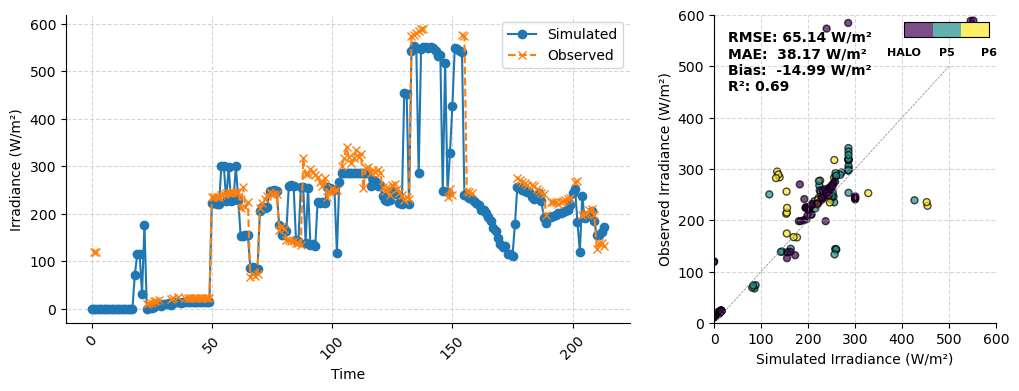

In [15]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib.colors as mcolors

fig, (ax, ax_scatter) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [2, 1]})

# Convert airplane column to categorical to get codes and categories
airplane_cat = ds_to_sim['airplane'].to_series().astype('category')
airplane_codes = airplane_cat.cat.codes
airplane_types = airplane_cat.cat.categories
n_colors = len(airplane_types)

# Main plot
ax.plot(ds_sim_alt.eglo / 1e3, marker='o', linestyle='-', label='Simulated')
ax.plot(ds_to_sim.F_down_solar, marker='x', linestyle='--', label='Observed')
ax.set_xlabel('Time')
ax.set_ylabel('Irradiance (W/m²)')
ax.legend()
ax.tick_params(axis='x', rotation=45)


# Scatter plot
cmap = plt.get_cmap('viridis', n_colors)
scatter = ax_scatter.scatter(ds_sim_alt.eglo / 1e3, ds_to_sim.F_down_solar, c=airplane_codes, cmap=cmap, s=25, alpha=0.7, edgecolor='k')
ax_scatter.set_xlabel('Simulated Irradiance (W/m²)')
ax_scatter.set_ylabel('Observed Irradiance (W/m²)')
ax_scatter.set_xlim(0, 600)
ax_scatter.set_ylim(0, 600)
ax_scatter.plot(np.arange(0, 600, 100), np.arange(0, 600, 100), color='gray', linestyle='--', linewidth=0.5)

### calculate the correlation coefficient, rmse and bias


from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X = ds_sim_alt.eglo.values / 1000
Y = ds_to_sim.F_down_solar.values
nan_mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[nan_mask]
Y = Y[nan_mask]

rmse = np.sqrt(mean_squared_error(X, Y))
bias = np.mean(X - Y)
r2 = r2_score(X, Y)
mae = mean_absolute_error(X, Y)

stats_text = f'RMSE: {rmse:.2f} W/m²\nMAE:  {mae:.2f} W/m²\nBias:  {bias:.2f} W/m²\nR²: {r2:.2f}'
ax_scatter.text(0.05, 0.95, stats_text, transform=ax_scatter.transAxes, fontsize=10, verticalalignment='top', fontweight='bold',)


# Create an inset colorbar
cax = inset_axes(ax_scatter, width="30%", height="5%", loc='upper right')
norm = mcolors.BoundaryNorm(np.arange(n_colors + 1) - 0.5, n_colors)
cb = fig.colorbar(scatter, cax=cax, orientation='horizontal', ticks=np.arange(n_colors), norm=norm)
cb.set_ticklabels(airplane_types, fontweight='bold')
cb.ax.tick_params(labelsize=8)
# remove colorbar ticks and spines
cax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True, labeltop=False)
cax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)


for a in [ax, ax_scatter]:
    a.grid(True, linestyle='--', alpha=0.5)
    a.spines[['top', 'right']].set_visible(False)   


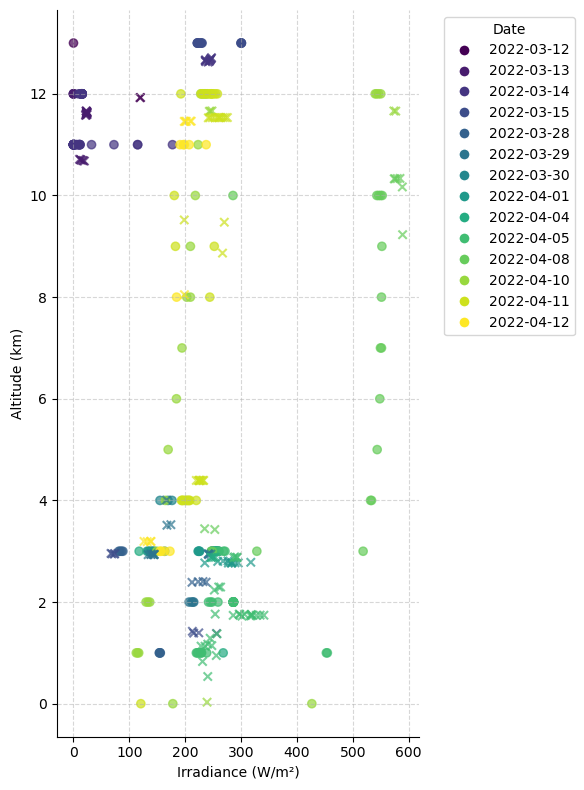

In [16]:
alt = ds_sim_alt.eglo.altitude.values

fig, ax = plt.subplots(1, figsize=(6,8))

ds_to_sim['z'] = ds['Alt'] / 1e3# Convert altitude to km for plotting

# Create categorical data for coloring by day
day_cat = ds_to_sim.time.to_series().dt.date.astype('category')
day_codes = day_cat.cat.codes
day_types = day_cat.cat.categories
n_colors = len(day_types)
cmap = plt.get_cmap('viridis', n_colors)


# Scatter plot for simulated data
scatter_sim = ax.scatter(ds_sim_alt.eglo.values / 1e3, alt, c=day_codes, cmap=cmap, marker='o', label='Simulated', alpha=0.7)
# Scatter plot for observed data
scatter_obs = ax.scatter(ds_to_sim.F_down_solar.values, ds_to_sim.z.values, c=day_codes, cmap=cmap, marker='x', label='Observed', alpha=0.7)

# Create a legend for the days
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(i), markersize=8) for i in range(n_colors)]
labels = [d.strftime('%Y-%m-%d') for d in day_types]
ax.legend(handles, labels, title="Date", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

ax.set_ylabel('Altitude (km)')
ax.set_xlabel('Irradiance (W/m²)')
ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()

## Comparing pyRadtran Simulations with Aircraft Observations and published Results

Text(0.05, 0.95, 'RMSE: 65.14 W/m²\nMAE:  38.17 W/m²\nBias:  -14.99 W/m²\nR²: 0.69')

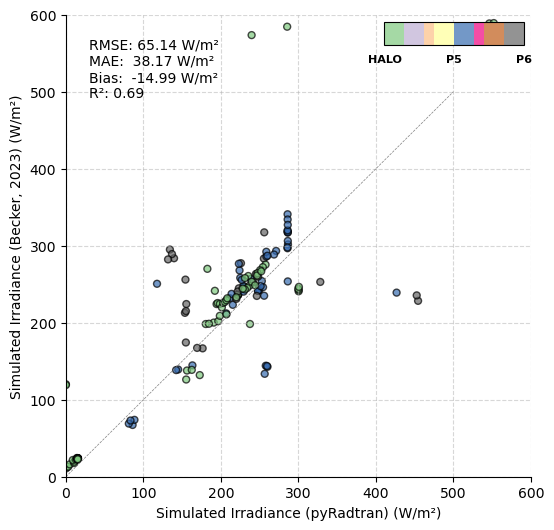

In [19]:
X = ds_sim_alt['eglo']
Y = ds_to_sim['F_down_solar']

fig, ax_scatter = plt.subplots(1, 1, figsize=(6, 6))

# Scatter plot
cmap = plt.get_cmap('Accent', n_colors)
scatter = ax_scatter.scatter(X / 1e3, Y, c=airplane_codes, cmap=cmap, s=25, alpha=0.7, edgecolor='k')
ax_scatter.set_xlabel('Simulated Irradiance (pyRadtran) (W/m²)')
ax_scatter.set_ylabel('Simulated Irradiance (Becker, 2023) (W/m²)')

n_colors = len(airplane_types)

# Set limits and add diagonal line
ax_scatter.set_xlim(0, 600)
ax_scatter.set_ylim(0, 600)
ax_scatter.plot(np.arange(0, 600, 100), np.arange(0, 600, 100), color='gray', linestyle='--', linewidth=0.5)
# Create an inset colorbar
cax = inset_axes(ax_scatter, width="30%", height="5%", loc='upper right')
norm = mcolors.BoundaryNorm(np.arange(n_colors + 1) - 0.5, n_colors)
cb = fig.colorbar(scatter, cax=cax, orientation='horizontal', ticks=np.arange(n_colors), norm=norm)
cb.set_ticklabels(airplane_types, fontweight='bold')
cb.ax.tick_params(labelsize=8)
# remove colorbar ticks and spines
cax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True, labeltop=False)
cax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)   
for a in [ax_scatter]:
    a.grid(True, linestyle='--', alpha=0.5)
    a.spines[['top', 'right']].set_visible(False)

# Calculate the correlation coefficient, RMSE, and bias
nan_mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[nan_mask].values / 1000  # Convert to W/m
Y = Y[nan_mask].values

rmse = np.sqrt(mean_squared_error(X, Y))
bias = np.mean(X - Y)
r2 = r2_score(X, Y)
mae = mean_absolute_error(X, Y)

stats_text = f'RMSE: {rmse:.2f} W/m²\nMAE:  {mae:.2f} W/m²\nBias:  {bias:.2f} W/m²\nR²: {r2:.2f}'
ax_scatter.text(0.05, 0.95, stats_text, transform=ax_scatter.transAxes, fontsize=10, verticalalignment='top')

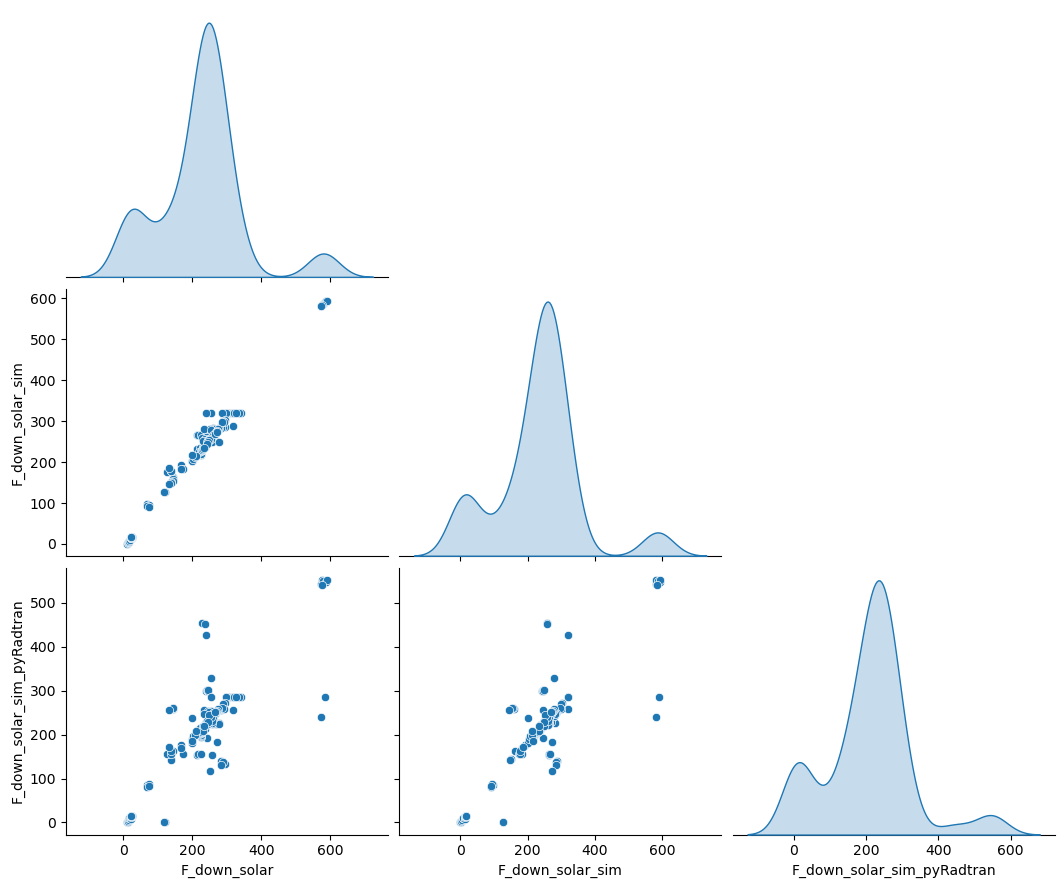

In [20]:
df_to_compare = ds[['F_down_solar', 'F_down_solar_sim']]
df_to_compare['F_down_solar_sim_pyRadtran'] = ('time', ds_sim_alt.eglo.values / 1000)  # Convert to W/m²

df_to_compare = df_to_compare.dropna('time', how='any').to_dataframe()
df_to_compare

### make this cool pandas scatter comparison plot where you can compare multiple columns 
import seaborn as sns
import matplotlib.pyplot as plt
#sns.set(style="whitegrid")
g = sns.pairplot(df_to_compare, kind='scatter', diag_kind='kde', markers=["o", "x"], height=3, aspect=1.2, corner=True)
